### Análisis de datos II
## Clustering

En esta notebook se ejemplifican técnicas de clustering y métodos de evaluación sobre el dataset de [automóbiles](https://uci-ics-mlr-prod.aws.uci.edu/dataset/10/automobile).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def plot_clusters(X, labels, core_sample_indices=None, ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    unique_labels = set(labels)

    # Cantidad de clusters y ruido
    n_clusters = len(unique_labels - {-1})
    n_noise = np.sum(labels == -1)

    print(f"Número de clusters: {n_clusters}")
    print(f"Ruido: {n_noise}")

    # Colores
    colors = [
        plt.cm.Spectral(each)
        for each in np.linspace(0, 1, len(unique_labels))
    ]

    # -------------------------
    # DBSCAN: core / no-core
    # -------------------------
    if core_sample_indices is not None:

        core_samples_mask = np.zeros_like(labels, dtype=bool)
        core_samples_mask[core_sample_indices] = True

        for k, col in zip(unique_labels, colors):

            if k == -1:
                col = [0, 0, 0, 1]

            class_member_mask = labels == k

            # Core
            xy = X[class_member_mask & core_samples_mask]
            ax.plot(
                xy[:, 0], xy[:, 1],
                "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=10
            )

            # No-core
            xy = X[class_member_mask & ~core_samples_mask]
            ax.plot(
                xy[:, 0], xy[:, 1],
                "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=5
            )

    # -------------------------
    # HDBSCAN
    # -------------------------
    else:

        for k, col in zip(unique_labels, colors):

            class_member_mask = labels == k

            if k == -1:
                col = [0, 0, 0, 1]
                size = 5
            else:
                size = 10

            xy = X[class_member_mask]

            ax.plot(
                xy[:, 0], xy[:, 1],
                "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=size
            )

    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.set_title(f"{n_clusters} clusters")

    plt.show()

---
### DATASET

In [3]:
columns = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration", "num-of-doors", "body-style", "drive-wheels",
    "engine-location", "wheel-base", "length", "width", "height", "curb-weight", "engine-type", "num-of-cylinders", 
    "engine-size", "fuel-system", "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", 
    "price"]

auto = pd.read_csv(
    '../datasets/automobile/imports-85.data',
    header=None,
    names=columns,
    na_values="?"
)

auto.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [4]:
auto.shape

(205, 26)

In [5]:
# eliminamos filas con target null.
auto = auto.dropna(subset=["price"])
auto = auto[auto["price"] != 0].reset_index(drop=True)

target = auto["price"].copy()
X = auto.drop(columns="price")

### Pipeline

- separar numéricas y categóricas
- imputar faltantes
- escalar las numéricas
- hacer one-hot encoding de las categóricas (para simplificar)
- aplicar clustering

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [7]:
# Identificar tipos de variables
numeric_cols = X.select_dtypes(include="number").columns
categorical_cols = X.select_dtypes(exclude="number").columns

In [8]:
# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_cols
        )
    ]
)

X_processed = preprocessor.fit_transform(X)

### Aplicamos PCA

No es requisito hacer reducción de dimensionalidad para hacer clustering. Pero si estamos con un dataset de alta dimensionalidad, es recomendado (recuerden la maldición de la dimensionalidad!)

Otra ventaja, es que nos facilita la interpretación visual de los clusters encontrados.

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90) # 90% de la información (varianza)
X_pca = pca.fit_transform(X_processed)

In [10]:
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
print(varianza_acumulada)

[0.37597036 0.5445671  0.62742181 0.68479222 0.73145155 0.76333863
 0.79340135 0.81922461 0.83927859 0.85898263 0.87577155 0.88935621
 0.90160119]


---
### K-means

In [11]:
from sklearn.cluster import KMeans

Vamos a calcular K-means para distintos valores de K. Para cada uno, calculamos el silhouette score.

In [12]:
from sklearn.metrics import silhouette_samples, silhouette_score

In [13]:
silhouette_scores = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i,  init = "k-means++", random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_pca)
        
    score = silhouette_score(X_pca, clusters)
    silhouette_scores.append(score)

    print(f"{i} clusters: silhouette = {score:.3f}")

2 clusters: silhouette = 0.265
3 clusters: silhouette = 0.242
4 clusters: silhouette = 0.188
5 clusters: silhouette = 0.206
6 clusters: silhouette = 0.229
7 clusters: silhouette = 0.260
8 clusters: silhouette = 0.237
9 clusters: silhouette = 0.234
10 clusters: silhouette = 0.231


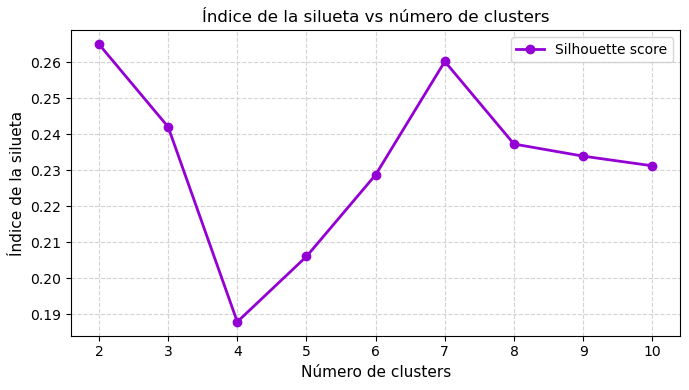

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(2, 11), silhouette_scores, "o-", color="darkviolet", lw=2, label="Silhouette score")
ax.set_xlabel("Número de clusters", fontsize=11)
ax.set_ylabel("Índice de la silueta", fontsize=11)
ax.set_xticks(np.arange(2, 11, step=1))
ax.set_title("Índice de la silueta vs número de clusters", fontsize=12)
ax.legend(fontsize=10)
plt.grid(True, ls='--', color='lightgray')
plt.tight_layout()
plt.show()

2 y 7 son buenos números de cluster según el índice promedio.

Veamos cómo se componen los 7 clusters con un gráfico de silueta.

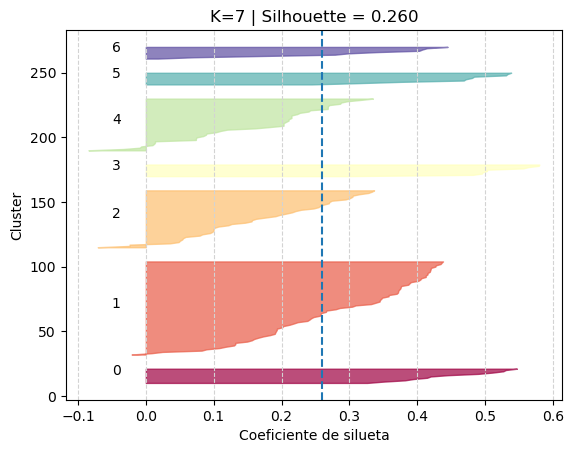

In [15]:
K=7
kmeans = KMeans(n_clusters=K,  init = "k-means++", random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

silhouette_vals = silhouette_samples(X_pca, clusters)
silhouette_avg = silhouette_score(X_pca, clusters)

colors = [plt.cm.Spectral(each) 
          for each in np.linspace(0, 1, len(np.unique(clusters)))]

y_lower = 10
for k in np.unique(clusters):

    vals = silhouette_vals[clusters == k]
    vals.sort()
    y_upper = y_lower + len(vals)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7, color=colors[k])
    plt.text(-0.05, (y_lower + y_upper) / 2, str(k))
    y_lower = y_upper + 10

plt.axvline(silhouette_avg, linestyle="--")
plt.grid(axis='x', ls='--', color='lightgray')

plt.xlabel("Coeficiente de silueta")
plt.ylabel("Cluster")
plt.title(f"K={K} | Silhouette = {silhouette_avg:.3f}")
plt.show()

La proporción de observaciones (autos) difiere bastante entre clusters. También vemos muchas muestras con índice negativo.

Decidimos quedarnos con K=2.

In [16]:
data = X_pca.copy()
K = 2
clusters = KMeans(n_clusters = K, init="k-means++", max_iter=300, n_init=10, random_state =123).fit_predict(data)

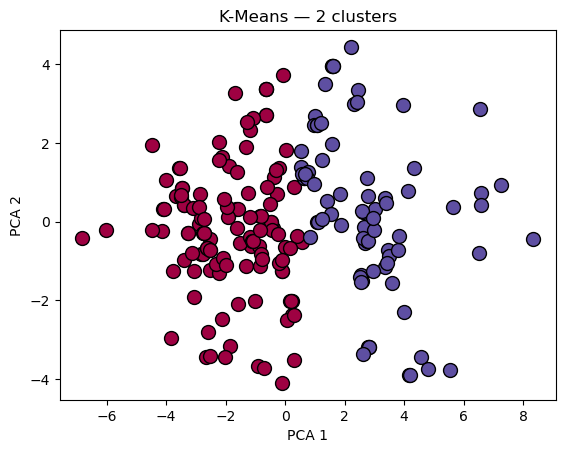

In [17]:
unique_labels = set(clusters)

colors = [
    plt.cm.Spectral(each)
    for each in np.linspace(0, 1, len(unique_labels))
]

for k, col in zip(unique_labels, colors):

    class_member_mask = clusters == k

    xy = X_pca[class_member_mask]

    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=10,
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title(f"K-Means — {K} clusters")
plt.show()

In [18]:
# agregamos las etiquetas al dataset
X['kmeans_pred'] = clusters

---
### GMM

In [19]:
from sklearn.mixture import GaussianMixture

In [20]:
silhouette_scores = []

for i in range(2, 11):
    gmm = GaussianMixture(n_components=i, random_state=42)
    clusters = gmm.fit_predict(X_pca)
        
    score = silhouette_score(X_pca, clusters)
    silhouette_scores.append(score)

    print(f"{i} clusters: silhouette = {score:.3f}")

2 clusters: silhouette = 0.252
3 clusters: silhouette = 0.233
4 clusters: silhouette = 0.185
5 clusters: silhouette = 0.175
6 clusters: silhouette = 0.174
7 clusters: silhouette = 0.197
8 clusters: silhouette = 0.181
9 clusters: silhouette = 0.188
10 clusters: silhouette = 0.210


Para GMM, también 2 resultó ser un buen número de clusters.

In [21]:
K=2
gmm = GaussianMixture(n_components=K, covariance_type='full',random_state=0)
clusters_gmm = gmm.fit_predict(X_pca)
proba = gmm.predict_proba(X_pca)

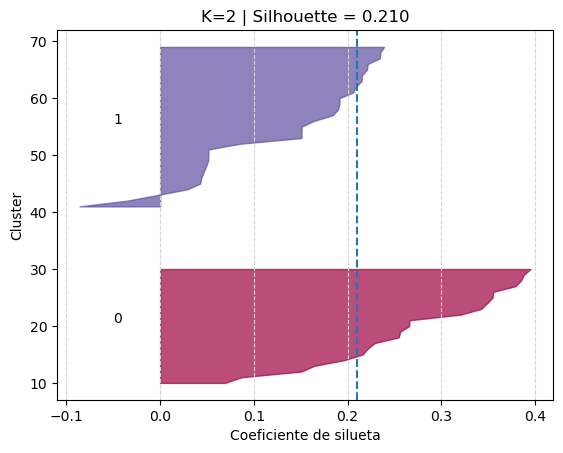

In [22]:
silhouette_vals = silhouette_samples(X_pca, clusters)
silhouette_avg = silhouette_score(X_pca, clusters)

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

y_lower = 10
for color, k in zip(colors, np.unique(clusters_gmm)):
    vals = silhouette_vals[clusters == k]
    vals.sort()
    y_upper = y_lower + len(vals)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7, color=color)
    plt.text(-0.05, (y_lower + y_upper) / 2, str(k))
    y_lower = y_upper + 10

plt.axvline(silhouette_avg, linestyle="--")
plt.grid(axis='x', ls='--', color='lightgray')

plt.xlabel("Coeficiente de silueta")
plt.ylabel("Cluster")
plt.title(f"K={K} | Silhouette = {silhouette_avg:.3f}")
plt.show()

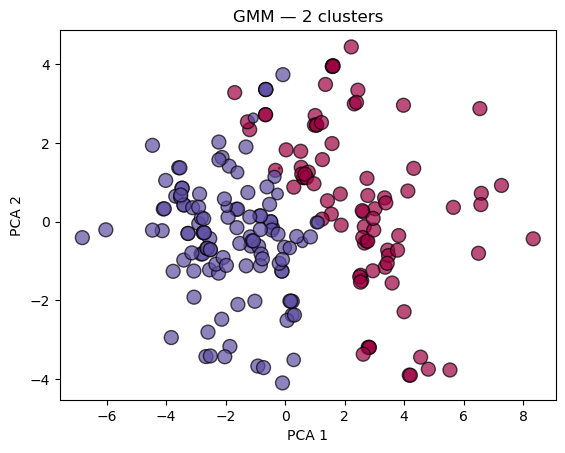

In [23]:
# para definir los tamaños de los puntos
prob = proba[np.arange(len(clusters_gmm)), clusters_gmm]
sizes = 100 * prob**10

unique_labels = set(clusters_gmm)

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):

    class_member_mask = clusters_gmm == k
    
    xy = X_pca[class_member_mask]
    sizes_k = sizes[class_member_mask]

    plt.scatter(xy[:, 0], xy[:, 1], s=sizes_k,
        c=[tuple(col)], edgecolor="k", alpha=0.7)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title(f"GMM — {K} clusters")
plt.show()

La separación en dos grupos se ve similar a la de K-means.

In [24]:
# agregamos las etiquetas al dataset
X['gmm_pred'] = clusters_gmm

---
### Clustering Jerárquico

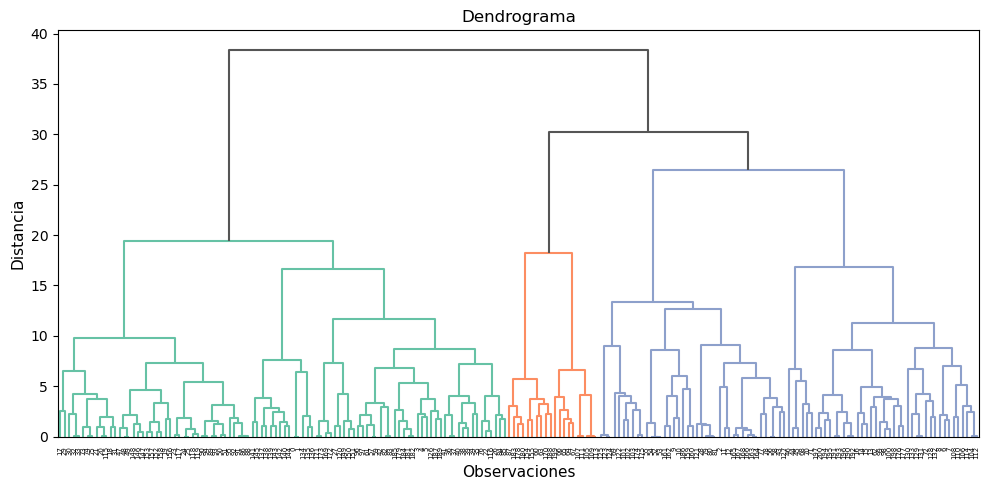

In [25]:
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage, set_link_color_palette
from matplotlib.colors import to_hex

# Calculamos el linkage
Z = linkage(X_pca, method='ward')

# Dibujamos el dendrograma
colors = [to_hex(c) for c in plt.cm.Set2.colors]
set_link_color_palette(colors)

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(Z, ax=ax, above_threshold_color="#555555")
set_link_color_palette(None)
ax.set_title("Dendrograma", fontsize=12)
ax.set_xlabel("Observaciones", fontsize=11)
ax.set_ylabel("Distancia", fontsize=11)
plt.tight_layout()
plt.show()

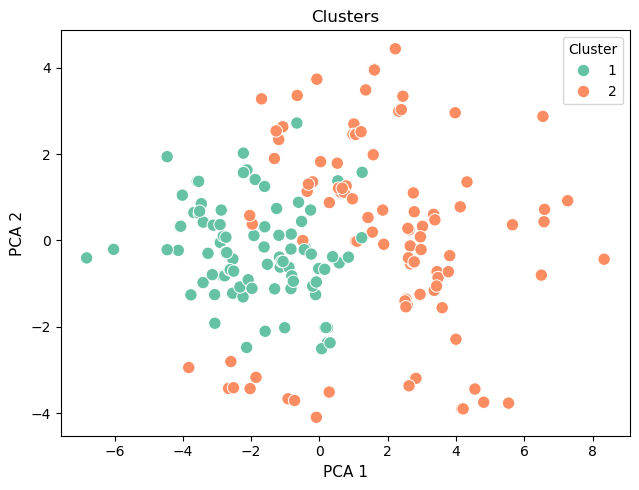

In [26]:
# Cortamos el dendrograma en un nivel para formar clusters
clusters = fcluster(Z, t=2, criterion='maxclust')

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette=colors[:2], ax=ax, s=80)
ax.set_title("Clusters", fontsize=12)
ax.set_xlabel("PCA 1", fontsize=11)
ax.set_ylabel("PCA 2", fontsize=11)
ax.legend(title="Cluster", fontsize=10)
plt.tight_layout()
plt.show()

Comparado con K-means y GMM, separa los puntos de manera diferente. Veamos qué pasa si cortamos en 3 clusters:

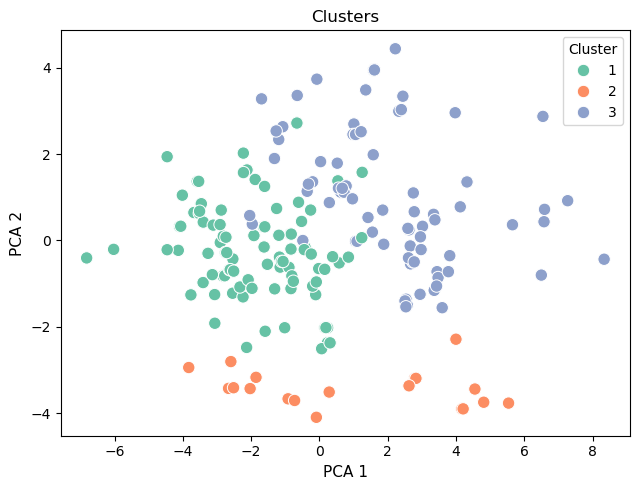

In [27]:
# Cortamos el dendrograma en un nivel para formar clusters
clusters = fcluster(Z, t=3, criterion='maxclust')

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette=colors[:3], ax=ax, s=80)
ax.set_title("Clusters", fontsize=12)
ax.set_xlabel("PCA 1", fontsize=11)
ax.set_ylabel("PCA 2", fontsize=11)
ax.legend(title="Cluster", fontsize=10)
plt.tight_layout()
plt.show()

Visualmente, no parece mala la separación en tres clusters generada a partir del dendrograma.

Aparece un tercer cluster está compuesto por autos con valores que comparten un rango chiquito de valores en la segunda componente de PCA.

In [28]:
# agregamos las etiquetas al dataset
X['jerarquico_pred'] = clusters

---
### DBSCAN

In [29]:
from sklearn.cluster import DBSCAN

In [30]:
data = X_pca.copy()
db = DBSCAN(eps=3).fit(data)
db

,eps,3
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


Número de clusters: 4
Ruido: 27


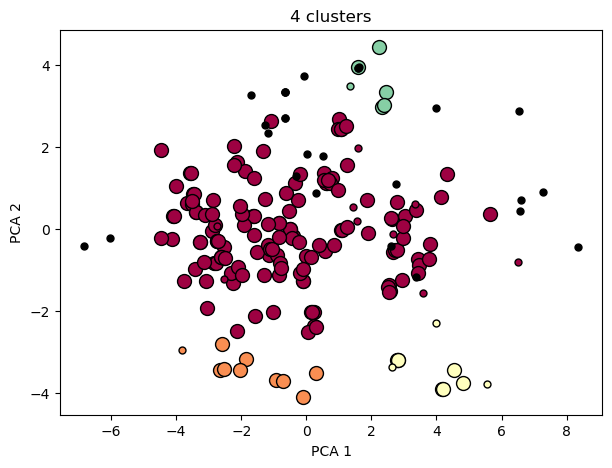

In [31]:
plot_clusters(X_pca, db.labels_, db.core_sample_indices_)

La clusterización basada en densidad nos da resultados bastante distintos e identifica algo de ruido. Agrandamos un poquito el radio de vecindad (epsilon) y reentrenamos.

Número de clusters: 2
Ruido: 12


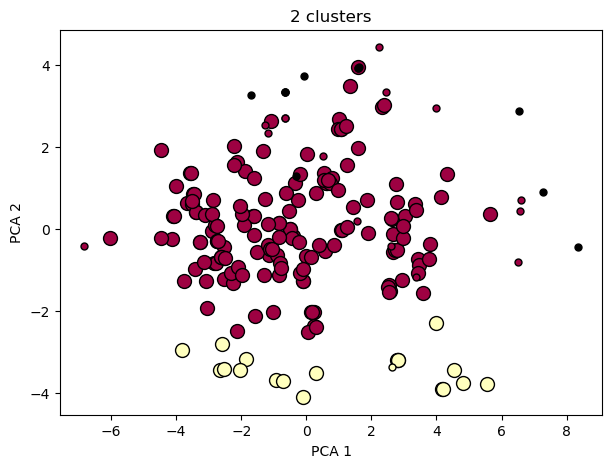

In [32]:
db = DBSCAN(eps=3.5, min_samples=6).fit(data)
plot_clusters(X_pca, db.labels_, db.core_sample_indices_)

In [33]:
# agregamos las etiquetas al dataset
X['dbscan_pred'] = db.labels_

---
### HDBSCAN

In [34]:
from sklearn.cluster import HDBSCAN

In [35]:
data = X_pca.copy()
hdb = HDBSCAN(min_cluster_size=5).fit(data)
hdb

,min_cluster_size,5
,min_samples,None
,cluster_selection_epsilon,0.0
,max_cluster_size,None
,metric,'euclidean'
,metric_params,None
,alpha,1.0
,algorithm,'auto'
,leaf_size,40
,n_jobs,None
,cluster_selection_method,'eom'


Número de clusters: 11
Ruido: 101


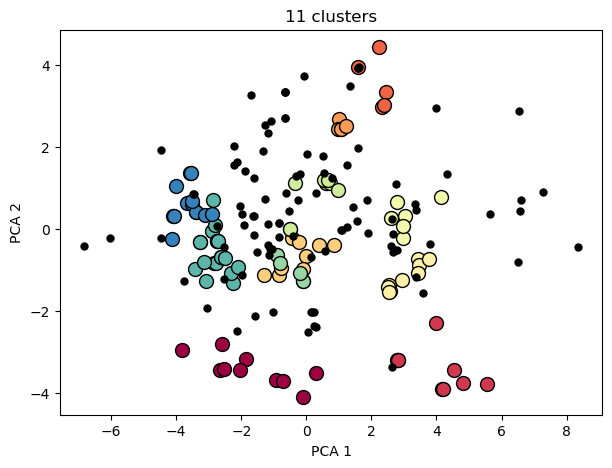

In [36]:
plot_clusters(X_pca, hdb.labels_)

HDBSCAN, por defecto, generó muchos clusters y demasiado ruido. Ajustamos el tamaño mínimo de cluster y reentrenamos.

Número de clusters: 2
Ruido: 16


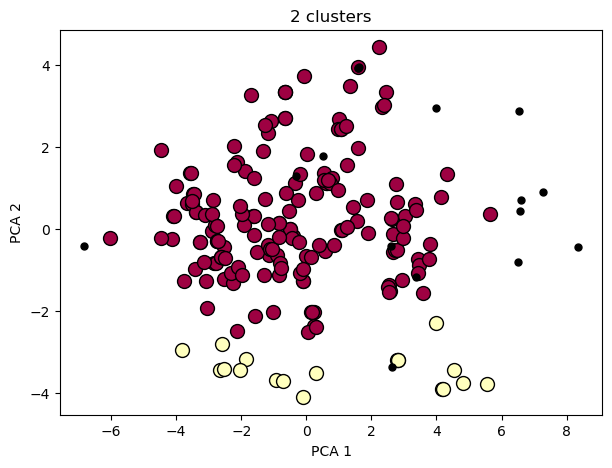

In [37]:
hdb = HDBSCAN(min_cluster_size=7).fit(data)
plot_clusters(X_pca, hdb.labels_)

In [38]:
# agregamos las etiquetas al dataset
X['hdbscan_pred'] = hdb.labels_

---
### RESUMEN

In [39]:
X.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,kmeans_pred,gmm_pred,jerarquico_pred,dbscan_pred,hdbscan_pred
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,0,0,1,0,0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,0,0,1,0,0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,1,0,3,0,-1
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,0,1,1,0,0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,1,0,1,0,0
5,2,NaN,audi,gas,std,two,sedan,fwd,front,99.8,...,8.5,110.0,5500.0,19,25,1,0,1,0,0
6,1,158.0,audi,gas,std,four,sedan,fwd,front,105.8,...,8.5,110.0,5500.0,19,25,1,0,3,0,0
7,1,NaN,audi,gas,std,four,wagon,fwd,front,105.8,...,8.5,110.0,5500.0,19,25,1,0,3,0,0
8,1,158.0,audi,gas,turbo,four,sedan,fwd,front,105.8,...,8.3,140.0,5500.0,17,20,1,0,3,0,0
9,2,192.0,bmw,gas,std,two,sedan,rwd,front,101.2,...,8.8,101.0,5800.0,23,29,0,0,3,0,0


#### Podemos explorar (EDA) cada agrupamiento por separado o comparar distintos agrupamientos entre sí.

In [40]:
# vemos los autos del cluster más chiquito identificado por el clustering jerárquico.
X[X['jerarquico_pred']==2]

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,kmeans_pred,gmm_pred,jerarquico_pred,dbscan_pred,hdbscan_pred
60,0,NaN,mazda,diesel,std,NaN,sedan,fwd,front,98.8,...,22.7,64.0,4650.0,36,42,0,1,2,1,1
63,0,NaN,mazda,diesel,std,four,sedan,rwd,front,104.9,...,22.0,72.0,4200.0,31,39,0,1,2,1,1
64,-1,93.0,mercedes-benz,diesel,turbo,four,sedan,rwd,front,110.0,...,21.5,123.0,4350.0,22,25,1,0,2,1,1
65,-1,93.0,mercedes-benz,diesel,turbo,four,wagon,rwd,front,110.0,...,21.5,123.0,4350.0,22,25,1,0,2,1,1
66,0,93.0,mercedes-benz,diesel,turbo,two,hardtop,rwd,front,106.7,...,21.5,123.0,4350.0,22,25,1,0,2,1,1
67,-1,93.0,mercedes-benz,diesel,turbo,four,sedan,rwd,front,115.6,...,21.5,123.0,4350.0,22,25,1,0,2,1,1
87,1,128.0,nissan,diesel,std,two,sedan,fwd,front,94.5,...,21.9,55.0,4800.0,45,50,0,1,2,1,1
105,0,161.0,peugot,diesel,turbo,four,sedan,rwd,front,107.9,...,21.0,95.0,4150.0,28,33,1,0,2,1,1
107,0,NaN,peugot,diesel,turbo,four,wagon,rwd,front,114.2,...,21.0,95.0,4150.0,25,25,1,0,2,1,1
109,0,161.0,peugot,diesel,turbo,four,sedan,rwd,front,107.9,...,21.0,95.0,4150.0,28,33,1,0,2,1,1


In [41]:
# Vemos los autos marcados como "ruido" por el algoritmo HDBSCAN.
X[X['hdbscan_pred']==-1]

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,kmeans_pred,gmm_pred,jerarquico_pred,dbscan_pred,hdbscan_pred
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,1,0,3,0,-1
17,2,121.0,chevrolet,gas,std,two,hatchback,fwd,front,88.4,...,9.5,48.0,5100.0,47,53,0,1,1,0,-1
44,0,145.0,jaguar,gas,std,four,sedan,rwd,front,113.0,...,8.1,176.0,4750.0,15,19,1,0,3,0,-1
45,0,NaN,jaguar,gas,std,four,sedan,rwd,front,113.0,...,8.1,176.0,4750.0,15,19,1,0,3,0,-1
46,0,NaN,jaguar,gas,std,two,sedan,rwd,front,102.0,...,11.5,262.0,5000.0,13,17,1,0,3,-1,-1
68,-1,NaN,mercedes-benz,gas,std,four,sedan,rwd,front,115.6,...,8.3,155.0,4750.0,16,18,1,0,3,0,-1
69,3,142.0,mercedes-benz,gas,std,two,convertible,rwd,front,96.6,...,8.3,155.0,4750.0,16,18,1,0,3,0,-1
70,0,NaN,mercedes-benz,gas,std,four,sedan,rwd,front,120.9,...,8.0,184.0,4500.0,14,16,1,0,3,-1,-1
71,1,NaN,mercedes-benz,gas,std,two,hardtop,rwd,front,112.0,...,8.0,184.0,4500.0,14,16,1,0,3,-1,-1
108,0,161.0,peugot,gas,std,four,sedan,rwd,front,107.9,...,8.4,95.0,5000.0,19,24,1,0,3,0,-1


### Comparación de resultados

No tenemos un ground truth (etiquetas reales), pero podemos medir el grado de acuerdo o consenso entre diferentes algoritmos.

In [42]:
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score

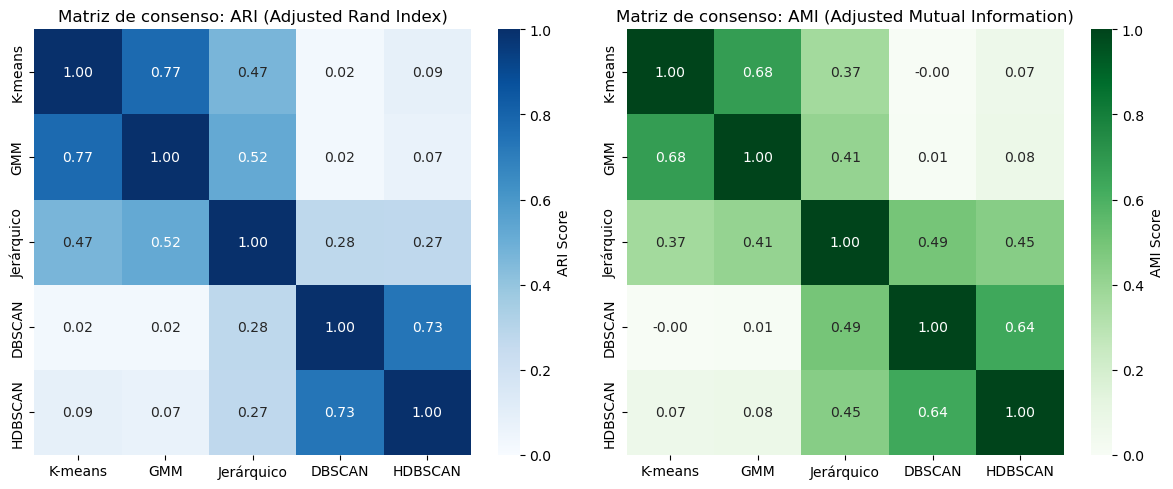

In [43]:
labels_dict = {
    "K-means":X['kmeans_pred'],
    "GMM":X['gmm_pred'],
    "Jerárquico":X['jerarquico_pred'],
    "DBSCAN":X['dbscan_pred'],
    "HDBSCAN":X['hdbscan_pred']
}

metodos = list(labels_dict.keys())
n = len(metodos)

matriz_ari = np.eye(n)
matriz_ami = np.eye(n)

# Calcula las métricas para cada par de métodos
for i in range(n):
  for j in range(n):
    if i != j:
      m1, m2 = metodos[i], metodos[j]
      matriz_ari[i, j] = adjusted_rand_score(labels_dict[m1], labels_dict[m2])
      matriz_ami[i, j] = adjusted_mutual_info_score(
          labels_dict[m1], labels_dict[m2]
      )

df_ari = pd.DataFrame(matriz_ari, index=metodos, columns=metodos)
df_ami = pd.DataFrame(matriz_ami, index=metodos, columns=metodos)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap para ARI
sns.heatmap(
    df_ari,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0,
    vmax=1,
    ax=axes[0],
    cbar_kws={'label': 'ARI Score'},
)
axes[0].set_title(
    'Matriz de consenso: ARI (Adjusted Rand Index)',
    fontsize=12
)

# Heatmap para AMI
sns.heatmap(
    df_ami,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    vmin=0,
    vmax=1,
    ax=axes[1],
    cbar_kws={'label': 'AMI Score'},
)
axes[1].set_title(
    'Matriz de consenso: AMI (Adjusted Mutual Information)',
    fontsize=12
)

plt.tight_layout()
plt.show()

Tal como habíamos observado, los resultados de K-means, GMM y clustering jerárquico comparten cierta información, los clusters son similares.

Los algoritmos basados en densidad, muestran resultados bastante distintos a los primeros tres modelos, pero parecidos entre sí.